(<Axes: >, <matplotlib.image.AxesImage at 0x122ca0910>)

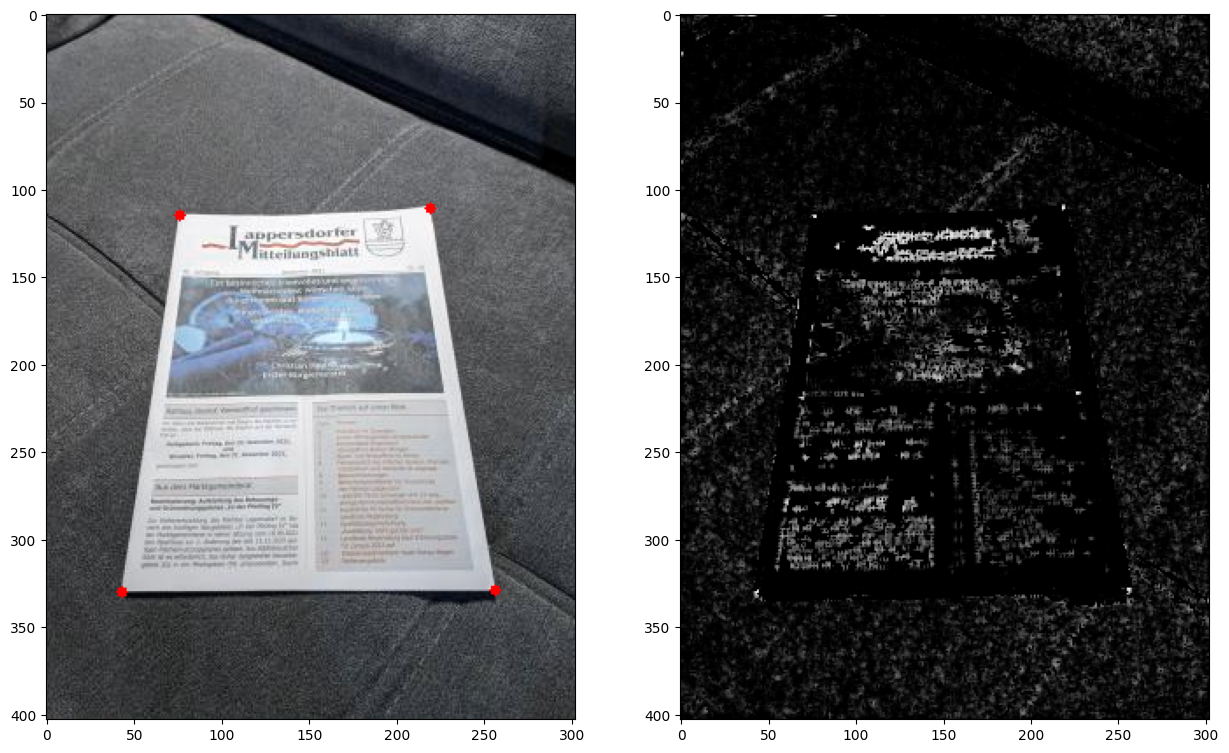

In [ ]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Let's read the image
img = cv2.imread('../../data/lesson_6/document.jpg')

if img is None:
    raise ValueError('Could not read the image')

# Convert it to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)/255
rows, cols = gray.shape
doc_is_dark = False

block_size = 2
gradient_kernel_size = 3
k_param = 0.04
cornerness = cv2.cornerHarris(gray, block_size, gradient_kernel_size, k_param)
cornerness[cornerness < 0] = 0
cornerness = np.log(cornerness + 1e-6)

# Detection thresholds
th_top_left, th_top_right = -1e6, -1e6
th_bottom_left, th_bottom_right = -1e6, -1e6

# Corner coordinates
opt_top_left, opt_top_right = None, None
opt_bottom_left, opt_bottom_right = None, None

# Size of each quadrant (in pixels)
quad_size = 7

# Let's now scan the Harris detection results
for r in range(quad_size, rows-quad_size):
    for c in range(quad_size, cols-quad_size):
        # Edges with too small cornerness score are discarded, -7 seems like a good value
        if cornerness[r, c] < -7:
            continue

        block = 255*gray[r-quad_size:r+quad_size+1, c-quad_size:c+quad_size+1]
        if doc_is_dark:
            block = 255 - block

        quad_top_left = block[:quad_size, :quad_size]
        quad_top_right = block[:quad_size, quad_size+1:]
        quad_bottom_left = block[quad_size+1:, :quad_size]
        quad_bottom_right = block[quad_size+1:, quad_size+1:]

        top_left_descriptor = np.mean(quad_bottom_right) - (
            np.mean(quad_top_left) + np.mean(quad_top_right) + np.mean(quad_bottom_left)
        )

        if top_left_descriptor > th_top_left:
            th_top_left = top_left_descriptor
            opt_top_left = (c, r)

        top_right_descriptor = np.mean(quad_bottom_left) - (
            np.mean(quad_top_right) + np.mean(quad_top_left) + np.mean(quad_bottom_right)
        )

        if top_right_descriptor > th_top_right:
            th_top_right = top_right_descriptor
            opt_top_right = (c, r)

        bottom_left_descriptor = np.mean(quad_top_right) - (
            np.mean(quad_bottom_left) + np.mean(quad_top_left) + np.mean(quad_bottom_right)
        )
        if bottom_left_descriptor > th_bottom_left:
            th_bottom_left = bottom_left_descriptor
            opt_bottom_left = (c, r)

        bottom_right_descriptor = np.mean(quad_top_left) - (
            np.mean(quad_bottom_right) + np.mean(quad_top_right) + np.mean(quad_bottom_left)
        )
        if bottom_right_descriptor > th_bottom_right:
            th_bottom_right = bottom_right_descriptor
            opt_bottom_right = (c, r)

if opt_top_left is None or opt_top_right is None or opt_bottom_left is None or opt_bottom_right is None:
    raise ValueError('Could not find all corners')

out = img.copy()
out = cv2.circle(out, opt_top_left, 3, (255, 0, 0), -1)
out = cv2.circle(out, opt_top_right, 3, (255, 0, 0), -1)
out = cv2.circle(out, opt_bottom_left, 3, (255, 0, 0), -1)
out = cv2.circle(out, opt_bottom_right, 3, (255, 0, 0), -1)

plt.subplot(121), plt.imshow(out)
plt.subplot(122), plt.imshow(cornerness, cmap='gray')

Does it matter whether the picture has been taken by a 1Mpx camera or a 12Mpx camera? How?
> Конечно, но для конкретной задачи думаю не играет сильно большую роль. Нам нужно по факту найти углы, то есть перепады яркости, 1Mpx должно быть достаточно, главное что бы контрастность была достаточной так как разница между фоном и документом при данном подходе решает гораздо большую роль (видно на моем не удавшемся эксперименте с более сложным фоном и тенями/пересечениями обьектов)

If we increased the resolution of the camera, what would you change in the current algorithm?
> Конечно, потому что у нас будет больше пикселей, а соответственно больше их плотность для нашего "угла" на сцене, то есть он будет иметь больше пикселей, а значит нужно будет увеличивать размер блока для поиска углов и кернела для поиска градиента. Но думаю тут намного лучше что бы камера нам передала меньше шума и четче цветопередачу.

(<Axes: >, <matplotlib.image.AxesImage at 0x123056fd0>)

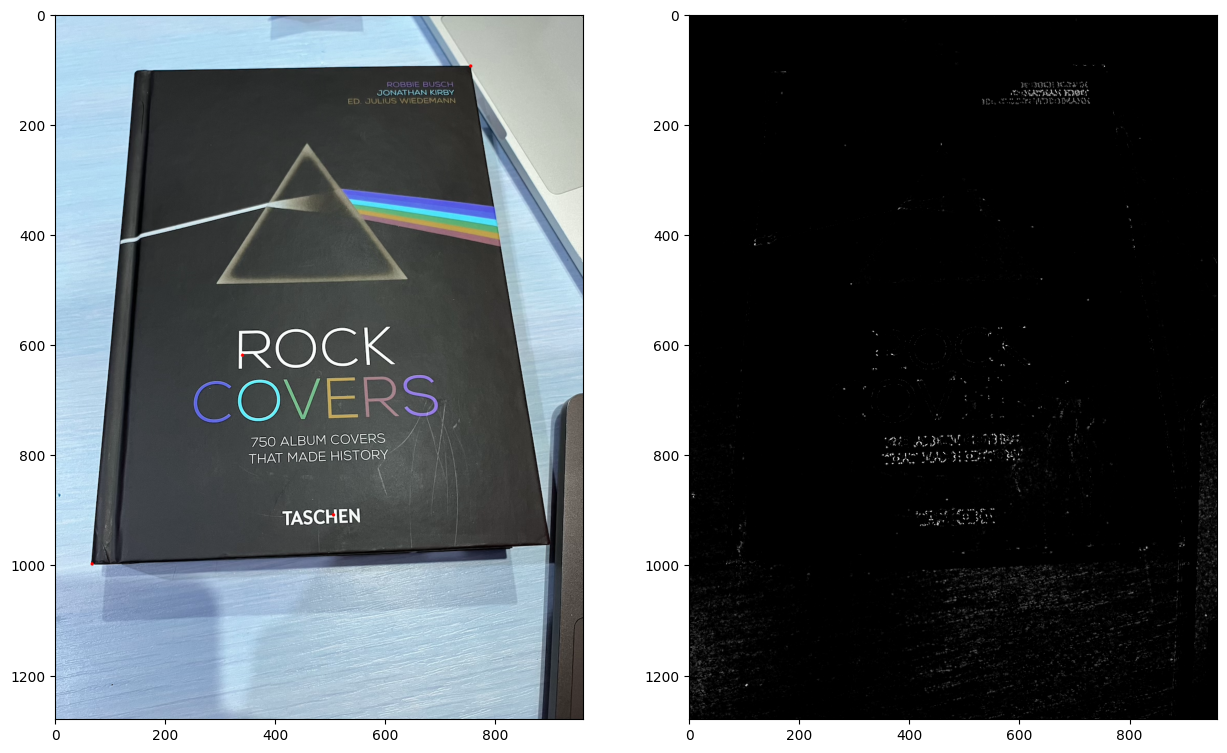

In [95]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Let's read the image
img = cv2.imread('../../data/lesson_6/book.jpg')

if img is None:
    raise ValueError('Could not read the image')

# Convert it to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)/255
rows, cols = gray.shape
doc_is_dark = True

block_size = 2
gradient_kernel_size = 3
k_param = 0.04
cornerness = cv2.cornerHarris(gray, block_size, gradient_kernel_size, k_param)
cornerness[cornerness < 0] = 0
cornerness = np.log(cornerness + 1e-6)

# Detection thresholds
th_top_left, th_top_right = -1e6, -1e6
th_bottom_left, th_bottom_right = -1e6, -1e6

# Corner coordinates
opt_top_left, opt_top_right = None, None
opt_bottom_left, opt_bottom_right = None, None

# Size of each quadrant (in pixels)
quad_size = 7

# Let's now scan the Harris detection results
for r in range(quad_size, rows-quad_size):
    for c in range(quad_size, cols-quad_size):
        # Edges with too small cornerness score are discarded, -7 seems like a good value
        if cornerness[r, c] < -7:
            continue

        block = 255*gray[r-quad_size:r+quad_size+1, c-quad_size:c+quad_size+1]
        if doc_is_dark:
            block = 255 - block

        quad_top_left = block[:quad_size, :quad_size]
        quad_top_right = block[:quad_size, quad_size+1:]
        quad_bottom_left = block[quad_size+1:, :quad_size]
        quad_bottom_right = block[quad_size+1:, quad_size+1:]

        top_left_descriptor = np.mean(quad_bottom_right) - (
            np.mean(quad_top_left) + np.mean(quad_top_right) + np.mean(quad_bottom_left)
        )

        if top_left_descriptor > th_top_left:
            th_top_left = top_left_descriptor
            opt_top_left = (c, r)

        top_right_descriptor = np.mean(quad_bottom_left) - (
            np.mean(quad_top_right) + np.mean(quad_top_left) + np.mean(quad_bottom_right)
        )

        if top_right_descriptor > th_top_right:
            th_top_right = top_right_descriptor
            opt_top_right = (c, r)

        bottom_left_descriptor = np.mean(quad_top_right) - (
            np.mean(quad_bottom_left) + np.mean(quad_top_left) + np.mean(quad_bottom_right)
        )
        if bottom_left_descriptor > th_bottom_left:
            th_bottom_left = bottom_left_descriptor
            opt_bottom_left = (c, r)

        bottom_right_descriptor = np.mean(quad_top_left) - (
            np.mean(quad_bottom_right) + np.mean(quad_top_right) + np.mean(quad_bottom_left)
        )
        if bottom_right_descriptor > th_bottom_right:
            th_bottom_right = bottom_right_descriptor
            opt_bottom_right = (c, r)

if opt_top_left is None or opt_top_right is None or opt_bottom_left is None or opt_bottom_right is None:
    raise ValueError('Could not find all corners')

out = img.copy()
out = cv2.circle(out, opt_top_left, 3, (255, 0, 0), -1)
out = cv2.circle(out, opt_top_right, 3, (255, 0, 0), -1)
out = cv2.circle(out, opt_bottom_left, 3, (255, 0, 0), -1)
out = cv2.circle(out, opt_bottom_right, 3, (255, 0, 0), -1)

plt.subplot(121), plt.imshow(out)
plt.subplot(122), plt.imshow(cornerness, cmap='gray')